# Mini-projekt analizy danych Netflix

## importy + czyszczenie danych

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import datetime as dttm
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.cluster import KMeans
from IPython.display import display
pd.set_option('display.max_colwidth', None)

netflix_data = pd.read_csv(r'C:\Users\asnguyen\Documents\Datasets\Netflix\netflix_titles.csv', sep=',', header=0)
netflix_data['date_added'] = pd.to_datetime(netflix_data['date_added'].str.strip(), format='%B %d, %Y')
netflix_data['year_added'] = netflix_data['date_added'].dt.year
netflix_data['cast'] = netflix_data['cast'].str.split(', ')
netflix_data['prim_country'] = netflix_data['country'].str.partition(sep=', ')[0] # bierzemy tylko pierwszy kraj produkcji jako ten główny
netflix_data['country'] = netflix_data['country'].str.split(', ')
netflix_data['listed_in'] = netflix_data['listed_in'].str.split(', ')
nulls = netflix_data.isnull().mean()
display((nulls[nulls > 0] * 100).round(2)) # procentowy udział braków w kolumnach

netflix_data['duration'] = netflix_data['duration'].fillna(netflix_data['duration'].dropna().mode()) # trochę oszukujemy system
num_na = netflix_data.select_dtypes(include=np.number).columns
for col in num_na:
    netflix_data[col] = netflix_data[col].fillna(int(netflix_data[col].dropna().mean())) # tak naprawdę nie ma żadnych braków numerycznych
cat_na = netflix_data.columns[~netflix_data.columns.isin(num_na)].drop(['duration'])
for col in cat_na:
    netflix_data[col] = netflix_data[col].fillna('missing')
display(netflix_data.head())

netflix_train, netflix_test = train_test_split(netflix_data, test_size=0.2, random_state=67) # jakbyśmy chcieli jakieś predykcje robić w przyszłości
netflix_train = pd.DataFrame(netflix_train); netflix_test = pd.DataFrame(netflix_test)

director        29.91
cast             9.37
country          9.44
date_added       0.11
rating           0.05
duration         0.03
year_added       0.11
prim_country     9.44
dtype: float64

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,prim_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,missing,[United States],2021-09-25 00:00:00,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.",2021.0,United States
1,s2,TV Show,Blood & Water,missing,"[Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng]",[South Africa],2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.",2021.0,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"[Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera]",missing,2021-09-24 00:00:00,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV Action & Adventure]","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.",2021.0,missing
3,s4,TV Show,Jailbirds New Orleans,missing,missing,missing,2021-09-24 00:00:00,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.",2021.0,missing
4,s5,TV Show,Kota Factory,missing,"[Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar]",[India],2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, TV Comedies]","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.",2021.0,India


## Poznanie danych (EDA)

In [173]:
display(netflix_train.shape) # wiersze, kolumny
display(netflix_train.columns) # kategorie danych, trochę zbędne skoro już wcześniej wypisaliśmy

(7045, 14)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'prim_country'],
      dtype='str')

## Parę prostszych pytań + wykresy

,count,proc
type,,
Movie,4907,69.65
TV Show,2138,30.35


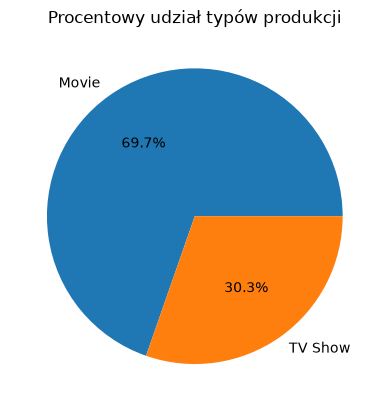

prim_country
United States     2537
India              820
missing            648
United Kingdom     483
Canada             227
Japan              206
France             178
South Korea        175
Spain              141
Mexico             106
Name: count, dtype: int64

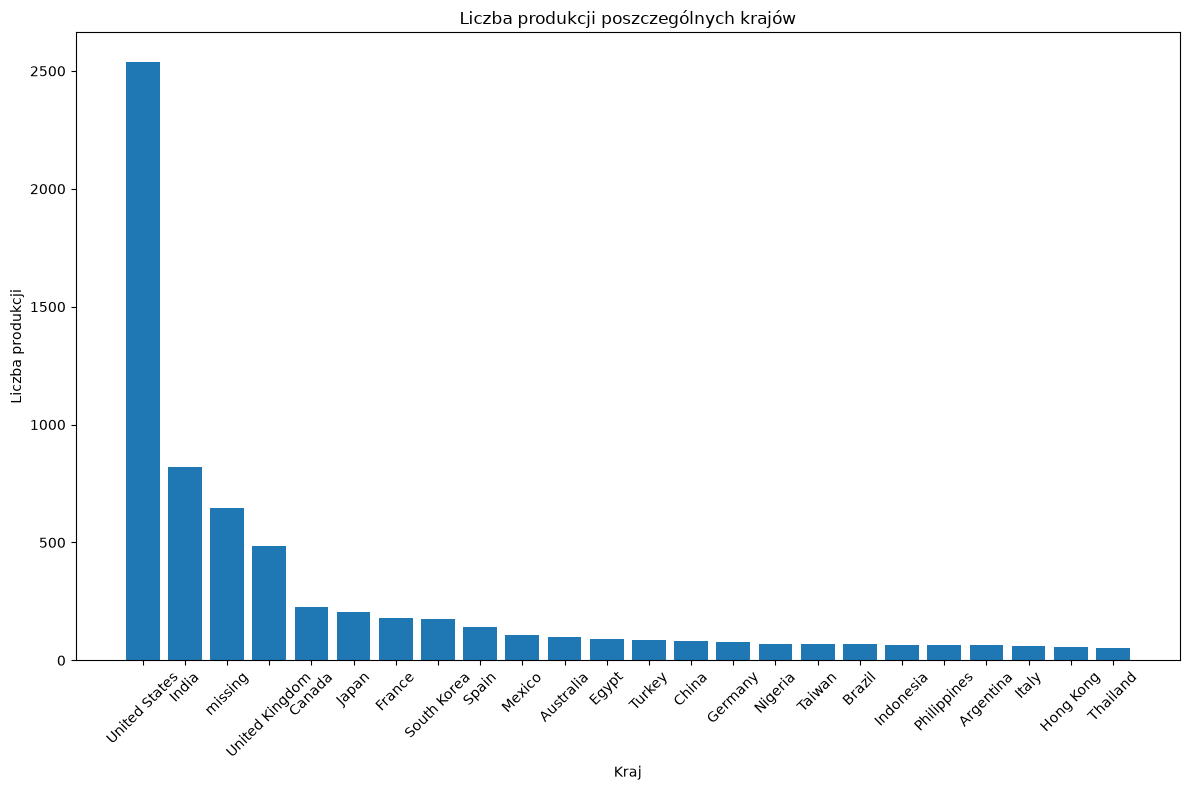

release_year
1925      1
1942      1
1943      2
1944      3
1945      3
       ... 
2017    826
2018    920
2019    822
2020    754
2021    457
Name: count, Length: 72, dtype: int64

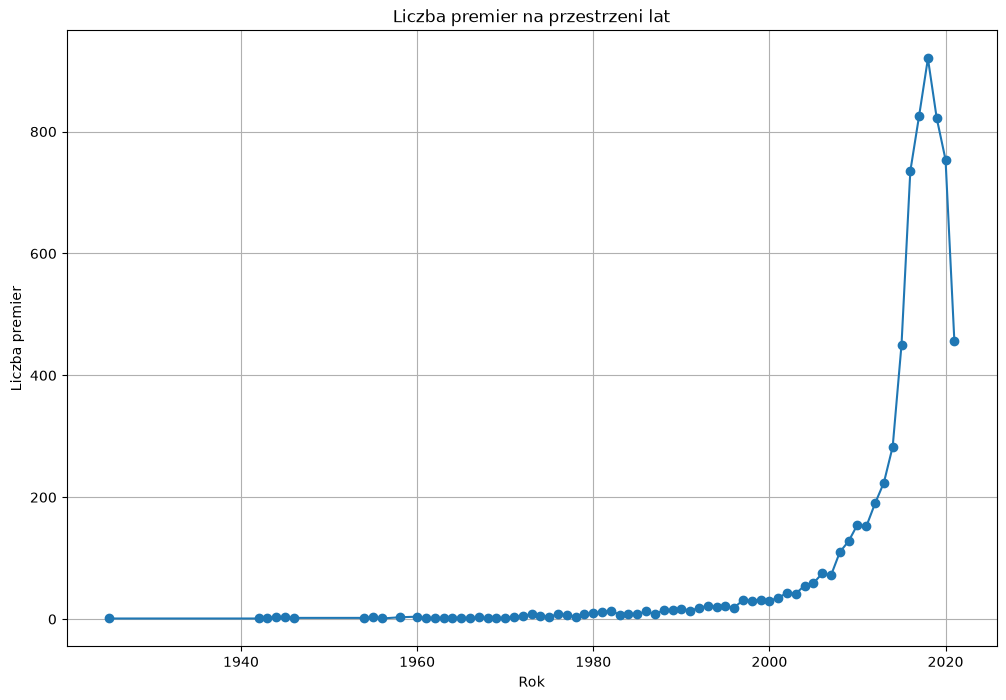

rating
TV-MA    2576
TV-14    1761
TV-PG     681
R         640
PG-13     388
TV-Y7     254
TV-Y      243
PG        226
TV-G      171
NR         56
Name: count, dtype: int64

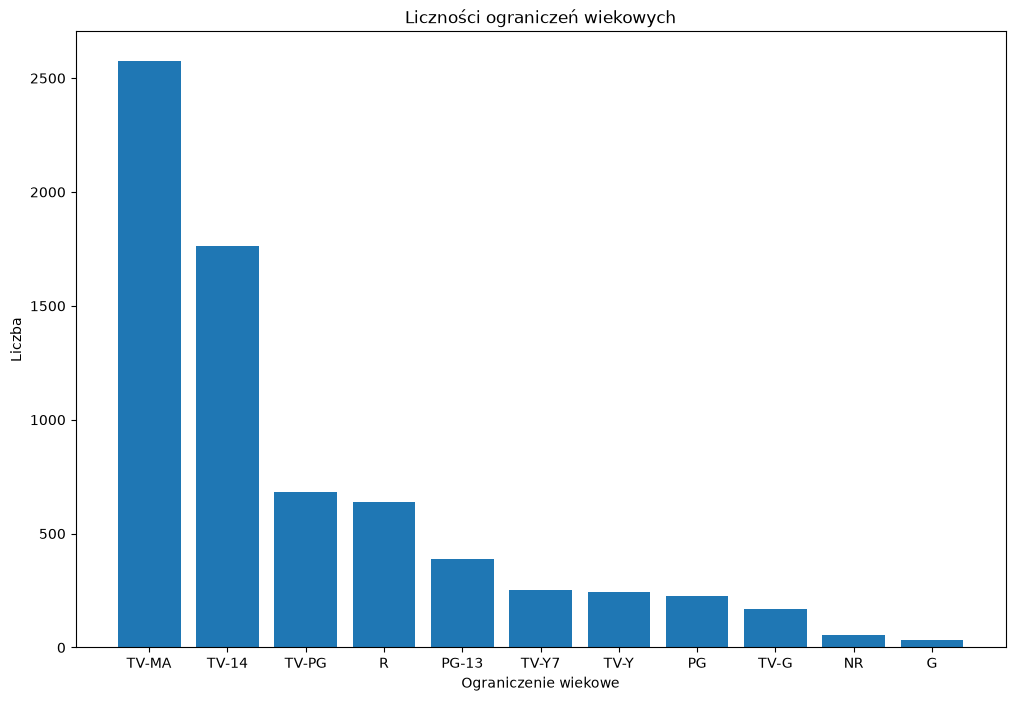

In [174]:
n = netflix_train.shape[0]
net_type = pd.DataFrame(netflix_train['type'].value_counts()).assign(proc = lambda x: (x['count']/n * 100).round(2)) # liczenie procentów bo czemu nie
display(net_type)
plt.pie(
    net_type['count'],
    labels=net_type.index,
    autopct='%1.1f%%'
)
plt.title('Procentowy udział typów produkcji')
plt.show()

net_country = netflix_train['prim_country'].value_counts()
net_country = net_country[net_country > 50] # odrzucamy bardzo małe kontrybucje
display(net_country.head(10)) # które kraje mają najwięcej produkcji?
plt.figure(figsize=(12,8))
plt.bar(net_country.index, net_country)
plt.title('Liczba produkcji poszczególnych krajów')
plt.xlabel('Kraj')
plt.ylabel('Liczba produkcji')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

net_year = netflix_train['release_year'].value_counts().sort_index()
display(net_year) # liczba premier na przestrzeni lat
plt.figure(figsize=(12,8))
plt.plot(net_year.index, net_year, marker='o')
plt.title('Liczba premier na przestrzeni lat')
plt.xlabel('Rok')
plt.ylabel('Liczba premier')
plt.grid(True)
plt.show()

net_age = netflix_train['rating'].value_counts()
net_age = net_age[net_age > 9] # odrzucamy małe kontrybucje
display(net_age.head(10)) # najpopularniejsze ograniczenia wiekowe
plt.figure(figsize=(12,8))
plt.bar(net_age.index, net_age)
plt.title('Liczności ograniczeń wiekowych')
plt.xlabel('Ograniczenie wiekowe')
plt.ylabel('Liczba')
plt.show()

## Kilka ciekawszych pytań

In [175]:
# Czy netflix częściej dodaje nowe czy stare produkcje?
# wykonaliśmy analizę dla wszystkich produkcji, nie tylko filmów
nowe = netflix_train[netflix_train['year_added']-netflix_train['release_year'] <= 3] # dodane niedługo po premierze
stare = netflix_train[netflix_train['year_added']-netflix_train['release_year'] >= 10] # dodane długo po premierze
inne = netflix_train[(netflix_train['year_added']-netflix_train['release_year']).between(4,9,inclusive='both')] # pozostałe
print(f'Liczba filmów nowych: {nowe.shape[0]}, starych: {stare.shape[0]}, pozostałych: {inne.shape[0]}')

# Jaka jest przeciętna długość filmu? Czy filmy z USA są na ogół dłuższe od filmów z Europy?
movies = netflix_train[netflix_train['type'].eq('Movie')]
movies['duration'] = pd.to_timedelta(movies['duration']).dt.total_seconds()//60 # czas trwania filmów w minutach
print(f'Średni czas trwania filmu to {int(movies['duration'].mean())} minut.')
print(f'Średni czas trwania filmu z USA to {int(movies[movies['prim_country'].eq('United States')]['duration'].mean())} minut.')
Europa = ('Albania, Andorra, Armenia, Austria, Azerbaijan, Belarus, Belgium, Bosnia and Herzegovina, Bulgaria, Croatia, Cyprus, Czechia, Denmark, Estonia, Finland, France, Georgia, Germany, Greece, Hungary, Iceland, Ireland, Italy, Kazakhstan, Kosovo, Latvia, Liechtenstein, Lithuania, Luxembourg, Malta, Moldova, Monaco, Montenegro, Netherlands, North Macedonia, Norway, Poland, Portugal, Romania, Russia, San Marino, Serbia, Slovakia, Slovenia, Spain, Sweden, Switzerland, Turkey, Ukraine, United Kingdom, Vatican City').split(', ')
print(f'Średni czas trwania filmu z Europy to {int(movies[movies['prim_country'].isin(Europa)]['duration'].mean())} minut.')
# Zatem filmy z Europy są średnio dłuższe o 5 minut od amerykańskich.
# Ciekawy wniosek -> filmy z innych części świata muszą być na ogół jeszcze dłuższe, być może jest korelacja między średnią długością filmu a poziomem rozwinięcia danej części świata.

# najczęstsze gatunki i tabela współwystępowania gatunków
display(netflix_train.explode('listed_in')['listed_in'].value_counts().head(10))

'''
genres = (
    netflix_train['listed_in']
    .explode()
    .str.get_dummies() # 0/1
    .groupby(level=0) # grupowanie po indeksie
    .sum() # złączenie liczności
)

lub

genres = (
    netflix_train.explode('listed_in')
      .assign(x=1)
      .pivot_table(
          index=netflix_train.index,
          columns='listed_in',
          values='x',
          aggfunc='sum',
          fill_value=0
      )
)
'''
genres = pd.crosstab(netflix_train['listed_in'].explode().index, netflix_train['listed_in'].explode()) # jednolinijkowiec
co_occurrence = genres.T @ genres # macierz współwystępowania
# heatmapy wyświetlają się bardzo słabo, jest za dużo gatunków
display(co_occurrence)

binary = genres.astype(bool)
intersection = binary.T @ binary
union = (
    binary.sum()
    .values[:, None]
    + binary.sum().values
    - intersection
)
jaccard = intersection / union # indeks Jaccarda, siła współwystępowania
display(jaccard)

# najpopularniejsi aktorzy
display(netflix_train.explode('cast')['cast'].value_counts().drop('missing').head(10))

# najpopularniejsi reżyserowie
display(netflix_train['director'].value_counts().drop('missing').head(10))

Liczba filmów nowych: 4814, starych: 1085, pozostałych: 1146
Średni czas trwania filmu to 99 minut.
Średni czas trwania filmu z USA to 92 minut.
Średni czas trwania filmu z Europy to 97 minut.


listed_in
International Movies        2223
Dramas                      1932
Comedies                    1321
International TV Shows      1081
Documentaries                696
Action & Adventure           679
TV Dramas                    614
Independent Movies           613
Children & Family Movies     505
Romantic Movies              499
Name: count, dtype: int64

listed_in,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
listed_in,,,,,,,,,,,,,,,,,,,,,
Action & Adventure,679,35,0,0,22,0,20,138,0,17,...,0,0,0,0,0,0,0,0,0,8
Anime Features,35,51,0,0,11,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Anime Series,0,0,148,0,0,0,0,0,15,0,...,1,0,0,6,0,0,0,7,12,0
British TV Shows,0,0,0,194,0,5,0,0,39,0,...,3,33,17,1,0,1,0,2,0,0
Children & Family Movies,22,11,0,0,505,0,6,215,0,2,...,0,0,0,0,0,0,0,0,0,0
Classic & Cult TV,0,0,0,5,0,22,0,0,3,0,...,5,7,4,2,1,4,0,0,0,0
Classic Movies,20,2,0,0,6,0,89,18,0,12,...,0,0,0,0,0,0,0,0,0,2
Comedies,138,0,0,0,215,0,18,1321,0,33,...,0,0,0,0,0,0,0,0,0,7
Crime TV Shows,0,0,15,39,0,3,0,0,380,0,...,34,20,149,3,15,2,0,9,0,0


listed_in,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
listed_in,,,,,,,,,,,,,,,,,,,,,
Action & Adventure,0.000737,0.001372,0.000000,0.000000,0.000845,0.000000,0.001304,0.000500,0.000000,0.001353,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000868
Anime Features,0.001372,0.009901,0.000000,0.000000,0.001802,0.000000,0.007194,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000
Anime Series,0.000000,0.000000,0.003390,0.000000,0.000000,0.000000,0.000000,0.000000,0.001898,0.000000,...,0.003584,0.000000,0.000000,0.004762,0.000000,0.000000,0.00,0.005236,0.004902,0.000000
British TV Shows,0.000000,0.000000,0.000000,0.002584,0.000000,0.004651,0.000000,0.000000,0.001745,0.000000,...,0.003077,0.001520,0.001239,0.003906,0.000000,0.003906,0.00,0.004219,0.000000,0.000000
Children & Family Movies,0.000845,0.001802,0.000000,0.000000,0.000991,0.000000,0.001686,0.000548,0.000000,0.001770,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000
Classic & Cult TV,0.000000,0.000000,0.000000,0.004651,0.000000,0.023256,0.000000,0.000000,0.002494,0.000000,...,0.006536,0.002058,0.001575,0.011905,0.010753,0.011905,0.00,0.000000,0.000000,0.000000
Classic Movies,0.001304,0.007194,0.000000,0.000000,0.001686,0.000000,0.005650,0.000710,0.000000,0.006711,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.001779
Comedies,0.000500,0.000000,0.000000,0.000000,0.000548,0.000000,0.000710,0.000379,0.000000,0.000724,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000557
Crime TV Shows,0.000000,0.000000,0.001898,0.001745,0.000000,0.002494,0.000000,0.000000,0.001318,0.000000,...,0.001957,0.001185,0.001007,0.002262,0.002217,0.002262,0.00,0.002364,0.000000,0.000000


cast
Anupam Kher         36
Akshay Kumar        27
Naseeruddin Shah    26
Shah Rukh Khan      25
Julie Tejwani       25
Paresh Rawal        25
Amitabh Bachchan    23
Rupa Bhimani        23
Takahiro Sakurai    23
Yuki Kaji           23
Name: count, dtype: int64

director
Raúl Campos, Jan Suter    15
Rajiv Chilaka             14
Marcus Raboy              14
Suhas Kadav               13
Jay Karas                 11
Youssef Chahine           11
Martin Scorsese           10
Cathy Garcia-Molina       10
Jay Chapman               10
David Dhawan               8
Name: count, dtype: int64

## Dodawanie nowych cech

In [176]:
netflix_train = netflix_train.assign(
    years_until_added = (netflix_train['year_added']-netflix_train['release_year']).astype(int),
    cast_cnt = netflix_train['cast'].apply(len), # liczność obsady
    country_cnt = netflix_train['country'].apply(len), # ile krajów produkcji
    genre_cnt = netflix_train['listed_in'].apply(len), # ile gatunków
    is_movie = netflix_train['type'].eq('Movie') # czy to film, czy serial?
)
netflix_train = netflix_train[~netflix_train['duration'].isna()] # mały procent produkcji nie ma wpisanej długości, wywalamy je
netflix_train['duration_num'] = np.nan
netflix_train.loc[netflix_train['is_movie'], 'duration_num'] = pd.to_timedelta(netflix_train.loc[netflix_train['is_movie'], 'duration']).dt.total_seconds().floordiv(60)
# przyjmujemy, że sezon średnio trwa sumarycznie 350 minut
netflix_train.loc[~netflix_train['is_movie'], 'duration_num'] = 350*netflix_train.loc[~netflix_train['is_movie'], 'duration'].str.partition(sep=' ')[0].astype(int)
netflix_train['is_movie'] = netflix_train['is_movie'].astype(int)

netflix_num = netflix_train.loc[:,netflix_train.select_dtypes(include=np.number).columns] # same dane numeryczne
netflix_num['duration_num'] = netflix_num['duration_num'].astype(int)
netflix_num['year_added'] = netflix_num['year_added'].astype(int)
display(netflix_num.head(10))

,release_year,year_added,years_until_added,cast_cnt,country_cnt,genre_cnt,is_movie,duration_num
3857,2019,2019,0,7,3,2,1,86
8179,2015,2018,3,11,1,2,1,87
3447,2016,2019,3,1,2,1,1,100
2408,2018,2020,2,6,1,3,0,350
825,2020,2021,1,9,1,3,0,700
6783,2017,2017,0,2,1,3,1,81
1813,2020,2020,0,7,1,1,0,1050
1866,2002,2020,18,8,1,2,1,156
2317,1990,2020,30,10,2,2,1,114
4803,2012,2018,6,1,1,1,1,69


## PCA

,0,1,2,3,4,5,6,7
0,0.979167,0.846154,0.031250,0.122449,0.285714,0.5,1.0,0.018254
1,0.937500,0.769231,0.062500,0.204082,0.000000,0.5,1.0,0.018474
2,0.947917,0.846154,0.062500,0.000000,0.142857,0.0,1.0,0.021333
3,0.968750,0.923077,0.052083,0.102041,0.000000,1.0,0.0,0.076314
4,0.989583,1.000000,0.041667,0.163265,0.000000,1.0,0.0,0.153288
5,0.958333,0.692308,0.031250,0.020408,0.000000,1.0,1.0,0.017154
6,0.989583,0.923077,0.031250,0.122449,0.000000,0.0,0.0,0.230262
7,0.802083,0.923077,0.218750,0.142857,0.000000,0.5,1.0,0.033649
8,0.677083,0.923077,0.343750,0.183673,0.142857,0.5,1.0,0.024412
9,0.906250,0.769231,0.093750,0.000000,0.000000,0.0,1.0,0.014515


,principal component 1,principal component 2
0,-0.112300,0.169565
1,-0.090435,-0.123225
2,-0.605686,-0.006355
3,0.405619,-0.076601
4,0.409335,-0.069524
5,0.398602,-0.095259
6,-0.589744,-0.140390
7,-0.087212,-0.119466
8,-0.091770,0.014445
9,-0.596564,-0.157013


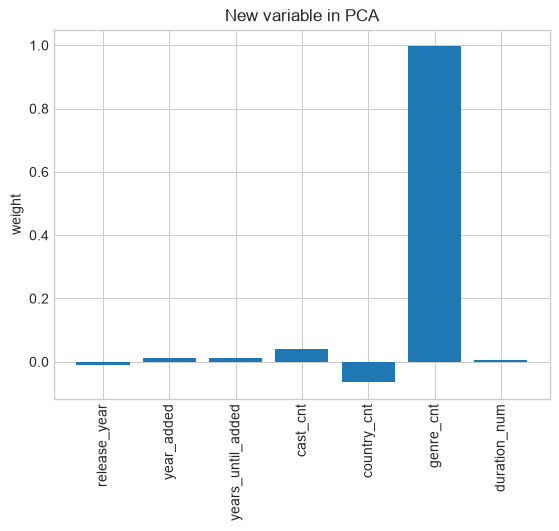

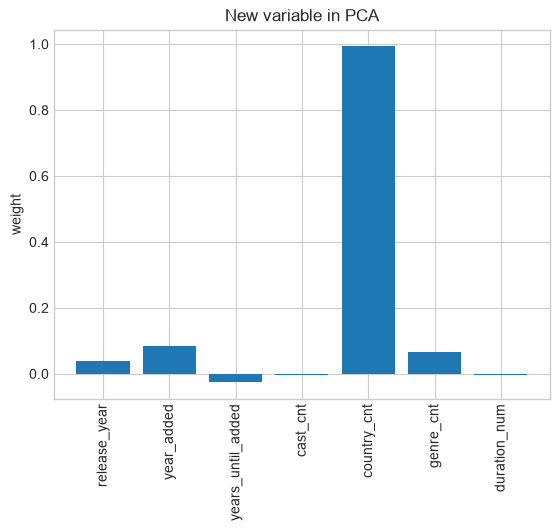

,PC1,PC2
0,-0.011497,0.037341
1,0.013243,0.083104
2,0.013290,-0.026087
3,0.041666,-0.002436
4,-0.065052,0.993392
5,0.996746,0.064629
7,0.006809,-0.002809


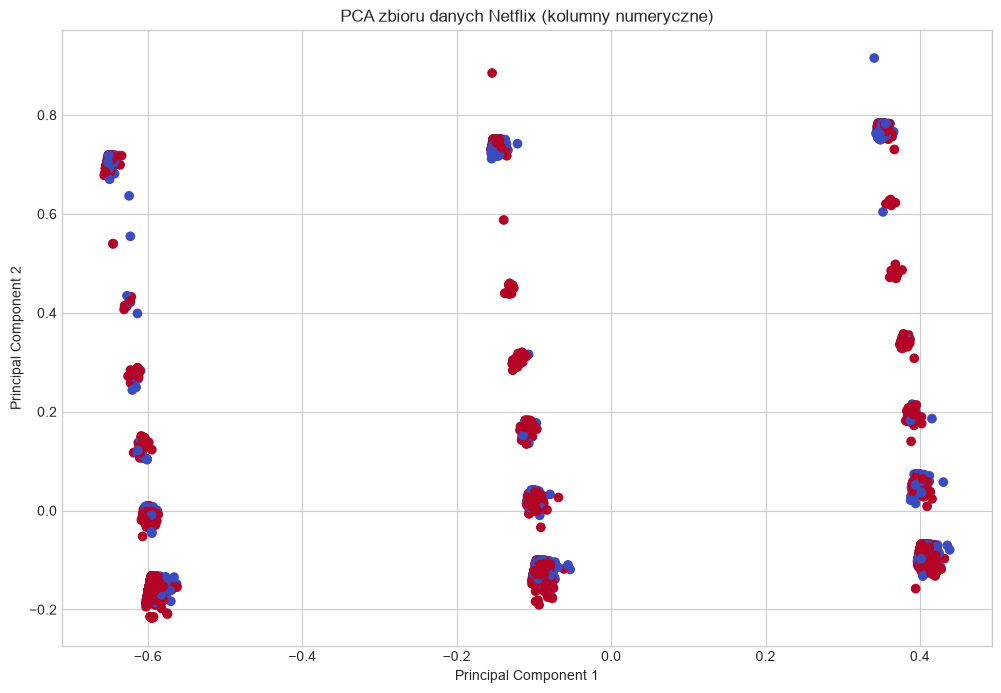

In [185]:
nominazer = MinMaxScaler()
netflix_nom = pd.DataFrame(nominazer.fit_transform(netflix_num)) # znominalizowane dane numeryczne
display(netflix_nom.head(10))

pca = PCA(n_components=2, random_state=67)
netflix_pca = pd.DataFrame(data = pca.fit_transform(netflix_nom.drop(6, axis=1)), columns = ['principal component 1', 'principal component 2'])
display(netflix_pca.head(10))

for component in pca.components_:
  plt.bar(netflix_num.drop('is_movie', axis=1).columns, component)
  plt.xticks(rotation=90)
  plt.title('New variable in PCA')
  plt.ylabel('weight')
  plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2'],
    index=netflix_nom.drop(6, axis=1).columns
)
display(loadings)

plt.figure(figsize=(12, 8))
plt.scatter(netflix_pca['principal component 1'], netflix_pca['principal component 2'], c=netflix_train['is_movie'], cmap='coolwarm')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA zbioru danych Netflix (kolumny numeryczne)')
plt.show()

Prawie cała waga została przypisana licznościom gatunków i krajów produkcji. Widzimy brak korelacji między tymi cechami a statusem film/serial.

## t-SNE

,t-SNE component 1,t-SNE component 2
0,-11.557391,29.909575
1,-6.453160,-76.253853
2,-37.789783,32.341309
3,59.727505,20.048786
4,47.942909,11.552395
5,15.258238,-25.723246
6,-67.863762,16.944229
7,-21.908428,-22.881243
8,-20.062416,-0.940664
9,-83.682739,-15.108382


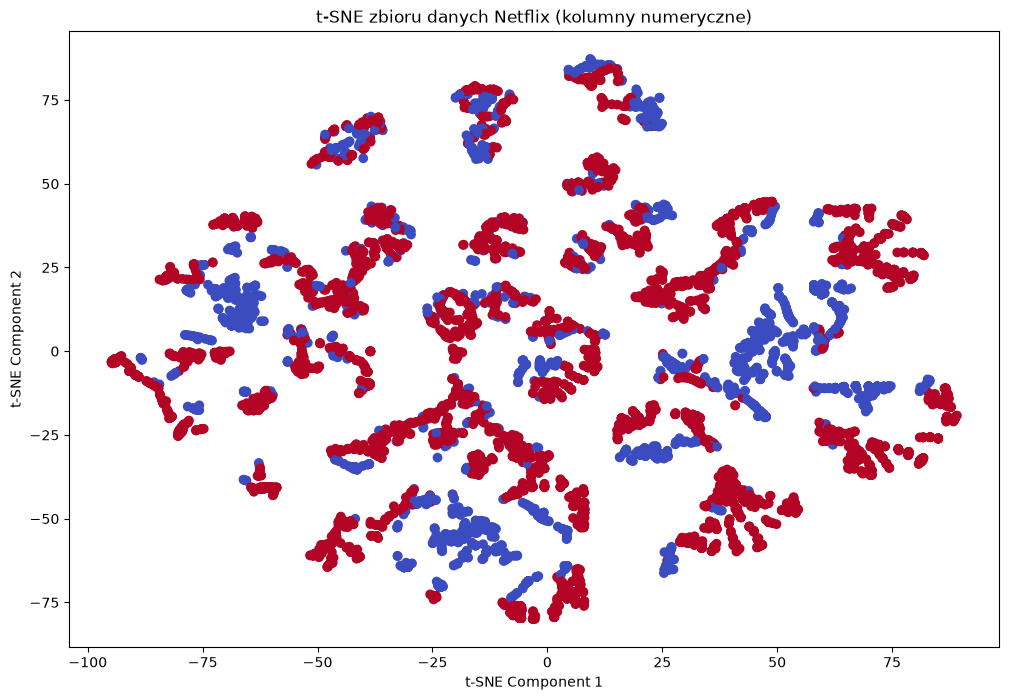

In [178]:
tsne = TSNE(n_components=2, random_state=67)
netflix_tsne = pd.DataFrame(data = tsne.fit_transform(netflix_nom.drop(6, axis=1)), columns = ['t-SNE component 1', 't-SNE component 2'])
display(netflix_tsne.head(10))

plt.figure(figsize=(12, 8))
plt.scatter(netflix_tsne['t-SNE component 1'], netflix_tsne['t-SNE component 2'], c=netflix_train['is_movie'], cmap='coolwarm')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE zbioru danych Netflix (kolumny numeryczne)')
plt.show()

Widzimy pewne rejony zdominowane przez filmy, a inne przez seriale, ale globalnie nie widzimy wyraźnej separacji pod tym względem.

## UMAP

c:\Users\asnguyen\Documents\Python\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP component 1,UMAP component 2
0,5.061075,16.662853
1,12.146861,17.359100
2,16.965502,-1.991592
3,2.810549,-17.633432
4,-2.873786,2.081269
5,3.321503,6.365128
6,19.079348,-2.746025
7,13.513579,10.966961
8,8.311817,15.711738
9,21.986677,-0.276897


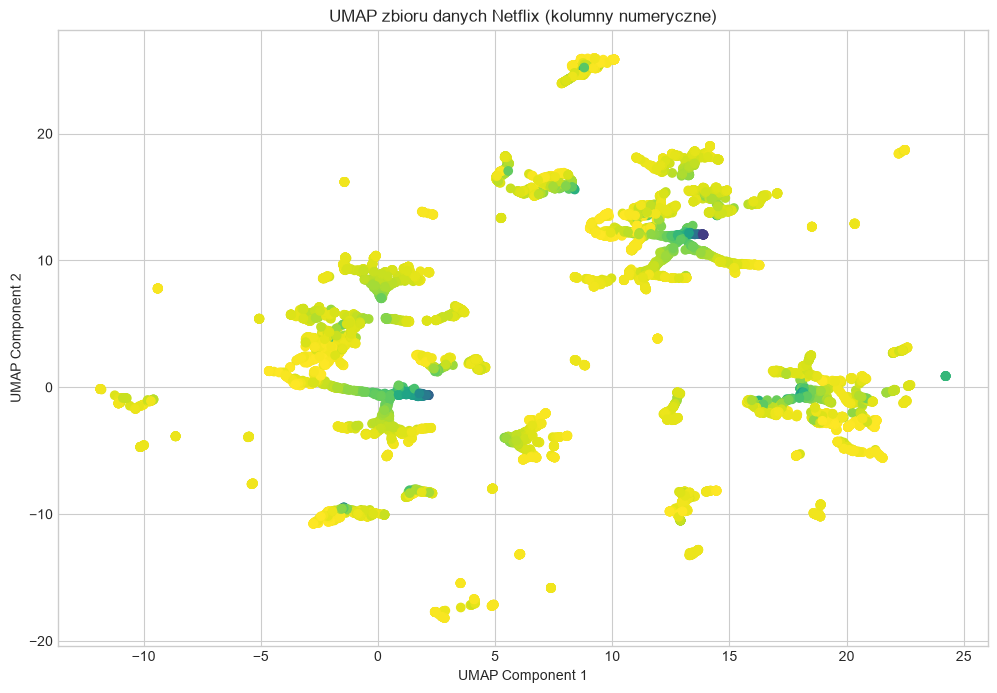

In [186]:
umap = UMAP(n_components=2, random_state=42)
netflix_umap = pd.DataFrame(data=umap.fit_transform(netflix_nom.drop(6, axis=1)), columns=['UMAP component 1', 'UMAP component 2'])
display(netflix_umap.head(10))

plt.figure(figsize=(12, 8))
plt.scatter(netflix_umap['UMAP component 1'], netflix_umap['UMAP component 2'], c=netflix_train['release_year'], cmap='viridis')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP zbioru danych Netflix (kolumny numeryczne)')
plt.show()

Podobnie jak w t-SNE, ale jest więcej wysepek. Wypróbowałem kolorowanie po roku premiery, ale też niewiele z tego widać.

## K-Means

'First 20 K-Means cluster labels: [9 6 3 8 4 5 3 2 9 3 2 5 4 2 2 9 9 5 4 3]'

'Shape of K-Means labels array: (7043,)'

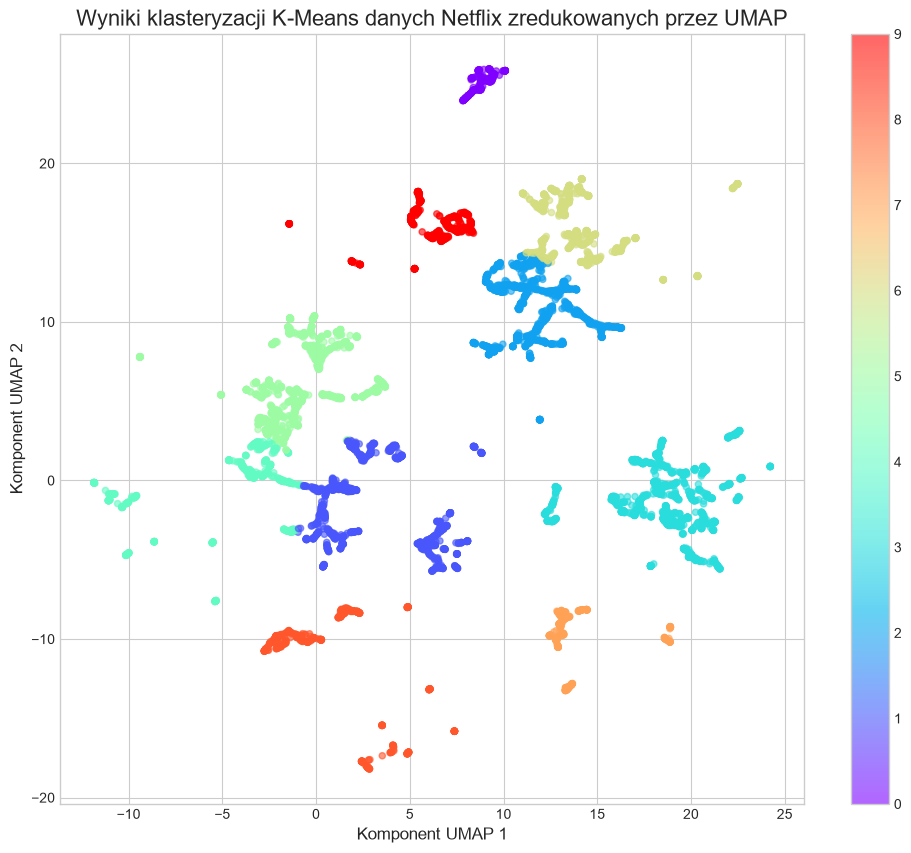

,duration_num,genre_cnt,country_cnt,years_until_added
cluster,,,,
0,255.86,2.00,7.00,2.78
1,142.82,3.00,1.27,9.74
2,314.82,2.00,1.02,7.66
3,260.84,1.00,1.26,4.11
4,261.65,3.00,1.00,2.38
5,393.19,2.98,1.03,2.86
6,227.22,2.00,1.00,2.20
7,154.29,1.00,4.94,1.26
8,265.53,3.00,4.39,2.71


is_movie,0,1
cluster,,
0,0.469828,0.530172
1,0.091463,0.908537
2,0.274396,0.725604
3,0.279908,0.720092
4,0.493827,0.506173
5,0.447266,0.552734
6,0.306705,0.693295
7,0.231034,0.768966
8,0.529528,0.470472


In [197]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(netflix_umap)
display(f"First 20 K-Means cluster labels: {kmeans_labels[:20]}") # do którego klastra należy pierwsze 20 pozycji
display(f"Shape of K-Means labels array: {kmeans_labels.shape}") # tyle mamy produkcji po prostu

plt.style.use('seaborn-v0_8-whitegrid') # używam stylu poleconego w kursie
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    netflix_umap.iloc[:,0], netflix_umap.iloc[:,1],
    c=kmeans_labels,  # użyj etykiet klastrów jako kolorów
    cmap='rainbow', # wybierz szatę kolorystyczną, więcej info: https://matplotlib.org/stable/users/explain/colors/colormaps.html
    alpha=0.6, # szczerze nie wiem co to robi
    s=20 # dopasuj wielkość punktów
)
plt.title('Wyniki klasteryzacji K-Means danych Netflix zredukowanych przez UMAP', fontsize=16)
plt.xlabel('Komponent UMAP 1', fontsize=12)
plt.ylabel('Komponent UMAP 2', fontsize=12)
plt.colorbar()
plt.show()

netflix_num["cluster"] = kmeans_labels
anal1 = netflix_num.groupby("cluster")[["duration_num","genre_cnt","country_cnt","years_until_added"]].mean().round(2)
display(anal1)

anal2 = pd.crosstab(
    netflix_num["cluster"],
    netflix_num["is_movie"],
    normalize="index"
)
display(anal2)

Podsumowując: ładne wykresy, ale ciężko z nich wiele odczytać. Możemy już coś powiedzieć o samych klastrach, ale przydałby się encoding na krajach produkcji, gatunkach i ratingach. Wtedy analiza dałaby o wiele więcej informacji.